In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from keras import Sequential 
from keras.layers import *
from keras.optimizers import Adam
from keras.callbacks import ReduceLROnPlateau, EarlyStopping
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import os

In [2]:
os.environ["OMP_NUM_THREADS"] = "12"
os.environ["TF_NUM_INTRAOP_THREADS"] = "12"
os.environ["TF_NUM_INTEROP_THREADS"] = "2"

tf.config.threading.set_intra_op_parallelism_threads(12)
tf.config.threading.set_inter_op_parallelism_threads(2)

print("Intra-op:", tf.config.threading.get_intra_op_parallelism_threads())
print("Inter-op:", tf.config.threading.get_inter_op_parallelism_threads())


Intra-op: 12
Inter-op: 2


In [12]:
df = pd.read_csv("../../../datasets/kaggle-airline_passenger_satisfaction/train.csv")

In [13]:
df.head(1).T

,0
id,0
Age,36
Flight Distance,694
Inflight wifi service,4
Departure/Arrival time convenient,4
Ease of Online booking,4
Gate location,3
Food and drink,1
Online boarding,4
Seat comfort,1


In [14]:
df.columns

Index(['id', 'Age', 'Flight Distance', 'Inflight wifi service',
       'Departure/Arrival time convenient', 'Ease of Online booking',
       'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
       'Inflight entertainment', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Cleanliness',
       'Departure Delay in Minutes', 'Arrival Delay in Minutes', 'Gender',
       'Customer Type', 'Type of Travel', 'Class', 'satisfaction'],
      dtype='str')

In [15]:
df[['Gender',
       'Customer Type', 'Type of Travel', 'Class', 'satisfaction']].info()

<class 'pandas.DataFrame'>
RangeIndex: 699635 entries, 0 to 699634
Data columns (total 5 columns):
 #   Column          Non-Null Count   Dtype
---  ------          --------------   -----
 0   Gender          699635 non-null  str  
 1   Customer Type   699635 non-null  str  
 2   Type of Travel  699635 non-null  str  
 3   Class           699635 non-null  str  
 4   satisfaction    699635 non-null  bool 
dtypes: bool(1), str(4)
memory usage: 22.0 MB


In [16]:
df['satisfaction'] = df['satisfaction'].astype(int)

In [17]:
df['satisfaction'].head(10)

0    0
1    1
2    0
3    0
4    0
5    0
6    1
7    0
8    1
9    0
Name: satisfaction, dtype: int64

In [18]:
df['satisfaction'].head(10)

0    0
1    1
2    0
3    0
4    0
5    0
6    1
7    0
8    1
9    0
Name: satisfaction, dtype: int64

In [19]:
df.isna().sum()

id                                     0
Age                                    0
Flight Distance                        0
Inflight wifi service                  0
Departure/Arrival time convenient      0
Ease of Online booking                 0
Gate location                          0
Food and drink                         0
Online boarding                        0
Seat comfort                           0
Inflight entertainment                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Cleanliness                            0
Departure Delay in Minutes             0
Arrival Delay in Minutes             292
Gender                                 0
Customer Type                          0
Type of Travel                         0
Class                                  0
satisfaction                           0
dtype: int64

In [20]:
df[df['Arrival Delay in Minutes'].isna()][['Gender',
       'Customer Type', 'Type of Travel', 'Class']].value_counts()

Gender  Customer Type      Type of Travel   Class   
Female  Loyal Customer     Business travel  Business    51
                           Personal Travel  Eco         51
Male    Loyal Customer     Personal Travel  Eco         49
                           Business travel  Business    45
Female  disloyal Customer  Business travel  Eco         22
Male    Loyal Customer     Business travel  Eco         17
Female  disloyal Customer  Business travel  Business    14
Male    disloyal Customer  Business travel  Eco         13
Female  Loyal Customer     Business travel  Eco         12
Male    Loyal Customer     Personal Travel  Eco Plus     5
        disloyal Customer  Business travel  Business     4
Female  Loyal Customer     Personal Travel  Eco Plus     3
        disloyal Customer  Business travel  Eco Plus     2
Male    Loyal Customer     Business travel  Eco Plus     2
Female  Loyal Customer     Personal Travel  Business     1
                           Business travel  Eco Plus     1
Nam

In [21]:
df.dropna(inplace = True)

In [22]:
df.shape

(699343, 23)

In [23]:
df.describe()

,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
count,699343.000000,699343.000000,699343.000000,699343.000000,699343.000000,699343.000000,699343.000000,699343.000000,699343.000000,699343.000000,699343.000000,699343.000000,699343.000000,699343.000000,699343.000000,699343.000000,699343.000000,699343.000000,699343.000000
mean,349820.496269,39.002531,1353.798525,2.778757,3.156138,2.813262,3.013706,3.265625,3.364226,3.568968,3.453916,3.517436,3.472831,3.805426,3.420329,3.380398,1.173596,1.134280,0.443606
std,201968.837438,13.800828,954.450464,1.280397,1.475381,1.329513,1.253994,1.300163,1.288479,1.275310,1.308135,1.238466,1.271748,1.079181,1.210601,1.277823,5.964274,5.749304,0.496810
min,0.000000,7.000000,67.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,174909.500000,27.000000,631.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,2.000000,3.000000,2.000000,3.000000,3.000000,2.000000,0.000000,0.000000,0.000000
50%,349830.000000,40.000000,954.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,0.000000,0.000000,0.000000
75%,524728.500000,50.000000,1814.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,5.000000,4.000000,5.000000,5.000000,4.000000,4.000000,0.000000,0.000000,1.000000
max,699634.000000,85.000000,4983.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,489.000000,491.000000,1.000000


In [24]:
df[df['Departure Delay in Minutes']>200]

,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,...,Baggage handling,Checkin service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Gender,Customer Type,Type of Travel,Class,satisfaction
4015,4015,7,533,2,5,2,4,2,5,5,...,5,5,5,205,197.0,Male,Loyal Customer,Personal Travel,Eco,0
18751,18751,32,1357,2,2,5,2,4,5,5,...,4,5,5,396,381.0,Female,Loyal Customer,Business travel,Business,1
94111,94111,25,3377,3,2,2,2,2,2,2,...,5,2,2,209,203.0,Male,Loyal Customer,Business travel,Business,1
127542,127542,21,533,3,4,3,4,3,0,1,...,4,1,1,204,197.0,Male,disloyal Customer,Business travel,Eco,0
222062,222062,54,3758,4,4,4,4,5,5,5,...,4,5,5,238,219.0,Female,Loyal Customer,Business travel,Business,1
359316,359316,24,707,4,4,4,4,4,2,2,...,4,2,1,205,201.0,Male,Loyal Customer,Personal Travel,Eco Plus,0
369131,369131,32,1042,1,3,3,3,1,1,1,...,3,1,1,381,353.0,Female,Loyal Customer,Business travel,Eco,1
411400,411400,25,447,3,3,3,4,3,5,5,...,5,5,5,472,446.0,Female,disloyal Customer,Business travel,Eco,0
426871,426871,57,3361,4,4,4,3,5,5,5,...,4,5,5,489,491.0,Female,Loyal Customer,Business travel,Business,1
428699,428699,8,678,3,5,3,3,3,1,3,...,5,3,3,214,201.0,Female,Loyal Customer,Personal Travel,Eco,0


<Axes: xlabel='Departure Delay in Minutes', ylabel='Arrival Delay in Minutes'>

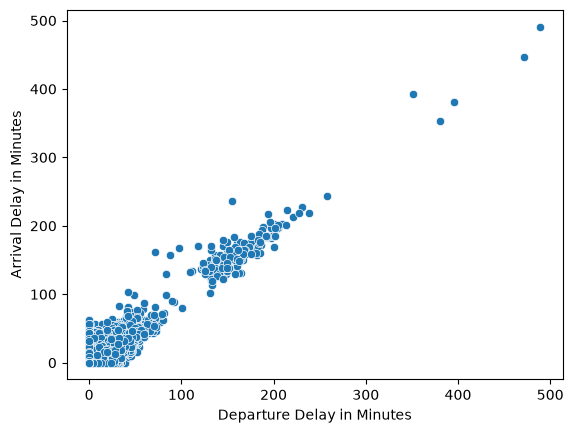

In [25]:
sns.scatterplot(
    x=df['Departure Delay in Minutes'],
    y=df['Arrival Delay in Minutes']
)


In [26]:
df.drop(columns=['id'], inplace = True)

In [27]:
df.head(2)

,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,...,Baggage handling,Checkin service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Gender,Customer Type,Type of Travel,Class,satisfaction
0,36,694,4,4,4,3,1,4,1,1,...,4,3,1,0,0.0,Female,Loyal Customer,Personal Travel,Eco,0
1,56,651,5,5,5,5,5,4,4,5,...,5,4,3,0,0.0,Male,Loyal Customer,Business travel,Business,1


In [28]:
df.to_csv("../../../datasets/kaggle-airline_passenger_satisfaction/cleaned_train.csv", index=False)

## prediction

In [4]:
df = pd.read_csv('../../datasets/kaggle-airline_passenger_satisfaction/cleaned_train.csv')

In [5]:
df.head(1).T

,0
Age,36
Flight Distance,694
Inflight wifi service,4
Departure/Arrival time convenient,4
Ease of Online booking,4
Gate location,3
Food and drink,1
Online boarding,4
Seat comfort,1
Inflight entertainment,1


In [6]:
x = df.drop(columns=['satisfaction'])
y = df['satisfaction']

In [14]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=1)

In [17]:
categorical_cols = ["Gender", "Customer Type", "Type of Travel", "Class"]
# categorical_cols = []
numerical_cols = ['Age', 'Flight Distance']

# for col in df.columns:
#     if col!='satisfaction' and col not in numerical_cols:
#         categorical_cols.append(col)

In [18]:
print(numerical_cols)
print(categorical_cols)

['Age', 'Flight Distance']
['Gender', 'Customer Type', 'Type of Travel', 'Class']


In [19]:
x_train_scaled = x_train.copy()
x_test_scaled = x_test.copy()

In [20]:
scaler = StandardScaler()

x_train_scaled[numerical_cols] = scaler.fit_transform(x_train[numerical_cols])
x_test_scaled[numerical_cols] = scaler.transform(x_test[numerical_cols])


In [21]:
x_train_scaled = pd.get_dummies(x_train_scaled, columns=categorical_cols, dtype=int)
x_test_scaled = pd.get_dummies(x_test_scaled, columns=categorical_cols, dtype=int)

In [ ]:
# gender_label_encoder = LabelEncoder()
# customer_type_label_encoder = LabelEncoder()
# type_of_travel_label_encoder = LabelEncoder()
# class_label_encoder = LabelEncoder()

# x_train_scaled['Gender'] = gender_label_encoder.fit_transform(x_train['Gender'])
# x_test_scaled['Gender'] = gender_label_encoder.transform(x_test['Gender'])

# x_train_scaled['Customer Type'] = customer_type_label_encoder.fit_transform(x_train['Customer Type'])
# x_test_scaled['Customer Type'] = customer_type_label_encoder.transform(x_test['Customer Type'])

# x_train_scaled['Type of Travel'] = type_of_travel_label_encoder.fit_transform(x_train['Type of Travel'])
# x_test_scaled['Type of Travel'] = type_of_travel_label_encoder.transform(x_test['Type of Travel'])

# x_train_scaled['Class'] = class_label_encoder.fit_transform(x_train['Class'])
# x_test_scaled['Class'] = class_label_encoder.transform(x_test['Class'])

In [22]:
x_train_scaled.head(2)

,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,...,Arrival Delay in Minutes,Gender_Female,Gender_Male,Customer Type_Loyal Customer,Customer Type_disloyal Customer,Type of Travel_Business travel,Type of Travel_Personal Travel,Class_Business,Class_Eco,Class_Eco Plus
13810,-1.086821,0.064903,1,2,1,4,3,1,3,3,...,0.0,1,0,0,1,1,0,1,0,0
224581,1.665874,-0.437658,3,5,3,3,4,4,4,1,...,0.0,1,0,1,0,0,1,0,0,1


In [23]:
x_test_scaled.head(2)

,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,...,Arrival Delay in Minutes,Gender_Female,Gender_Male,Customer Type_Loyal Customer,Customer Type_disloyal Customer,Type of Travel_Business travel,Type of Travel_Personal Travel,Class_Business,Class_Eco,Class_Eco Plus
460223,0.361966,-0.524559,4,4,3,3,1,5,4,5,...,0.0,1,0,1,0,0,1,0,1,0
601078,-0.217549,-0.802015,4,4,4,3,3,4,3,3,...,0.0,0,1,0,1,1,0,0,1,0


## model

In [40]:
model = Sequential()

model.add(Input(shape=(x_train_scaled.shape[1], )))

model.add(Dense(256 , kernel_initializer='he_uniform'))
model.add(BatchNormalization())
model.add(LeakyReLU(negative_slope=0.01))

# model.add(Dense(256 , kernel_initializer='he_uniform'))
# model.add(BatchNormalization())
# model.add(Activation('relu'))

model.add(Dense(128 , kernel_initializer='he_uniform'))
model.add(BatchNormalization())
model.add(LeakyReLU(negative_slope=0.01))
model.add(Dropout(0.2))

model.add(Dense(1))
model.add(Activation('sigmoid'))
 
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 256)            │         6,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │           129 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41,473 (162.00 KB)

 Trainable params: 40,705 (159.00 KB)

 Non-trainable params: 768 (3.00 KB)

In [41]:
model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])

In [42]:
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.6,
    patience=5,
    min_lr=1e-7
)

In [43]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    min_delta=0.00001,
    patience=20,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=False,
)

In [44]:
history = model.fit(
    x_train_scaled,
    y_train,
    epochs=350 ,
    batch_size=32,
    validation_split=0.2,
    callbacks=[lr_scheduler, early_stopping],
)

Epoch 1/350
13987/13987 ━━━━━━━━━━━━━━━━━━━━ 39s 3ms/step - accuracy: 0.9055 - loss: 0.2773 - val_accuracy: 0.9170 - val_loss: 0.2478 - learning_rate: 0.0010
Epoch 2/350
13987/13987 ━━━━━━━━━━━━━━━━━━━━ 36s 3ms/step - accuracy: 0.9143 - loss: 0.2583 - val_accuracy: 0.9207 - val_loss: 0.2426 - learning_rate: 0.0010
Epoch 3/350
13987/13987 ━━━━━━━━━━━━━━━━━━━━ 36s 3ms/step - accuracy: 0.9168 - loss: 0.2532 - val_accuracy: 0.9208 - val_loss: 0.2401 - learning_rate: 0.0010
Epoch 4/350
13987/13987 ━━━━━━━━━━━━━━━━━━━━ 36s 3ms/step - accuracy: 0.9179 - loss: 0.2499 - val_accuracy: 0.9221 - val_loss: 0.2385 - learning_rate: 0.0010
Epoch 5/350
13987/13987 ━━━━━━━━━━━━━━━━━━━━ 37s 3ms/step - accuracy: 0.9189 - loss: 0.2475 - val_accuracy: 0.9217 - val_loss: 0.2394 - learning_rate: 0.0010
Epoch 6/350
13987/13987 ━━━━━━━━━━━━━━━━━━━━ 37s 3ms/step - accuracy: 0.9197 - loss: 0.2461 - val_accuracy: 0.9216 - val_loss: 0.2381 - learning_rate: 0.0010
Epoch 7/350
13987/13987 ━━━━━━━━━━━━━━━━━━━━ 38s 3ms

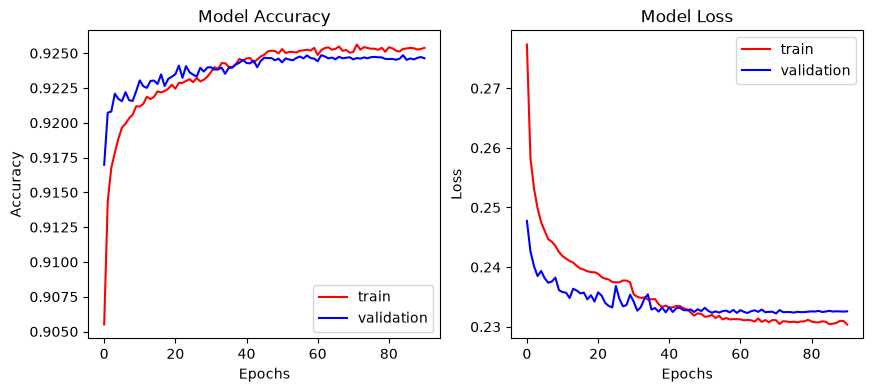

In [46]:
# Plot Accuracy
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], color='red', label='train')
plt.plot(history.history['val_accuracy'], color='blue', label='validation')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], color='red', label='train')
plt.plot(history.history['val_loss'], color='blue', label='validation')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [49]:
y_prob = model.predict(x_test_scaled)


4371/4371 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step


In [52]:
pd.Series(y_prob.flatten()).isna().sum()

np.int64(0)

In [53]:
y_prob

array([[0.09928337],
       [0.12618311],
       [0.03779795],
       ...,
       [0.96399164],
       [0.9561307 ],
       [0.9603021 ]], shape=(139869, 1), dtype=float32)

In [57]:
y_pred = np.where(y_prob>0.35, 1, 0)
y_pred = y_pred.flatten()

In [59]:
accuracy_score(y_test, y_pred )

0.9231137707426235

In [60]:
df_test = pd.read_csv("../../datasets/kaggle-airline_passenger_satisfaction/test.csv")

In [61]:
df_test[numerical_cols] = scaler.transform(df_test[numerical_cols])
df_test = pd.get_dummies(df_test, columns=categorical_cols, dtype=int)


# df_test['Gender'] = gender_label_encoder.transform(df_test['Gender'])
# df_test['Customer Type'] = customer_type_label_encoder.transform(df_test['Customer Type'])
# df_test['Type of Travel'] = type_of_travel_label_encoder.transform(df_test['Type of Travel'])
# df_test['Class'] = class_label_encoder.transform(df_test['Class'])

In [63]:
id = df_test['id']

In [64]:
df_test.drop(columns=['id'], inplace=True)

In [65]:
df_test

,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,...,Arrival Delay in Minutes,Gender_Female,Gender_Male,Customer Type_Loyal Customer,Customer Type_disloyal Customer,Type of Travel_Business travel,Type of Travel_Personal Travel,Class_Business,Class_Eco,Class_Eco Plus
0,-1.014381,-0.164391,4,4,4,2,3,4,3,3,...,0.0,1,0,0,1,1,0,0,1,0
1,-0.217549,-0.549688,5,5,5,5,5,4,5,5,...,0.0,0,1,1,0,1,0,0,1,0
2,0.434405,-0.923467,4,5,5,5,4,4,4,4,...,0.0,0,1,1,0,1,0,0,1,0
3,0.434405,-0.619837,2,2,2,5,3,2,3,3,...,0.0,1,0,0,1,1,0,1,0,0
4,-0.362427,-0.795733,1,2,1,1,2,1,2,2,...,0.0,0,1,1,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299839,-0.507306,0.388427,3,1,3,3,3,3,3,3,...,0.0,1,0,1,0,1,0,1,0,0
299840,-1.086821,-0.030374,3,3,3,4,3,3,3,2,...,0.0,1,0,0,1,1,0,0,1,0
299841,-0.434867,-1.218722,4,5,4,3,3,4,3,3,...,0.0,0,1,1,0,0,1,0,1,0
299842,1.448556,-0.707785,3,5,3,2,4,3,5,5,...,0.0,0,1,1,0,0,1,0,1,0


In [69]:
df_test['Arrival Delay in Minutes'] = df['Arrival Delay in Minutes'].fillna(0)

In [70]:
df_test.isna().sum()

Age                                  0
Flight Distance                      0
Inflight wifi service                0
Departure/Arrival time convenient    0
Ease of Online booking               0
Gate location                        0
Food and drink                       0
Online boarding                      0
Seat comfort                         0
Inflight entertainment               0
On-board service                     0
Leg room service                     0
Baggage handling                     0
Checkin service                      0
Cleanliness                          0
Departure Delay in Minutes           0
Arrival Delay in Minutes             0
Gender_Female                        0
Gender_Male                          0
Customer Type_Loyal Customer         0
Customer Type_disloyal Customer      0
Type of Travel_Business travel       0
Type of Travel_Personal Travel       0
Class_Business                       0
Class_Eco                            0
Class_Eco Plus           

In [71]:
y_prob = model.predict(df_test)

9371/9371 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step


In [73]:
y_prob = pd.Series(y_prob.flatten())
y_prob.isna().sum()

np.int64(0)

In [74]:
result = pd.concat([id, y_prob], axis=1)
result.columns = ['id', 'satisfaction']

In [75]:
result.to_csv('../../datasets/kaggle-airline_passenger_satisfaction/submission.csv', index=False)